In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from arch import arch_model

#Fetching data (NIFTY)
df = yf.download("^NSEI", start="2015-01-01", end="2022-12-31", progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

if 'Adj Close' in df.columns:
    df = df[['Adj Close']].copy()
else:
    df = df[['Close']].copy()
    df.rename(columns={'Close': 'Adj Close'}, inplace=True)

# 2. Calculate Log Returns and Scale for GARCH
df['Log_Returns'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))
df.dropna(inplace=True)
df['Scaled_Returns'] = df['Log_Returns'] * 100

# 3. Split into Training (2015-2019) and Testing (2020-2022)
train_df = df.loc[:'2019-12-31'].copy()
sim_df = df.loc['2020-01-01':].copy()

print(f"Training days: {len(train_df)} | Simulation days: {len(sim_df)}")

Fetching Nifty 50 Market Data...
YF.download() has changed argument auto_adjust default to True
Training days: 1221 | Simulation days: 746


In [ ]:
class BlackScholes:
    def __init__(self, S, K, T, r, sigma):
        self.S = S          # Current Stock Price
        self.K = K          # Strike Price
        self.T = T          # Time to Expiration (in years)
        self.r = r          # Risk-free rate (0.05)
        self.sigma = sigma  # Annualized Volatility (GARCH forecast)

    def _d1_d2(self):
        # Handle expiration day where T approaches 0 to avoid division by zero
        if self.T <= 0:
            return 0.0, 0.0
            
        d1 = (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        return d1, d2

    def call_price(self):
        if self.T <= 0:
            return max(0.0, self.S - self.K)
            
        d1, d2 = self._d1_d2()
        price = self.S * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)
        return price

    def call_delta(self):
        if self.T <= 0:
            return 1.0 if self.S > self.K else 0.0
            
        d1, _ = self._d1_d2()
        return norm.cdf(d1)

Test Call Price: 366.14
Test Call Delta: 0.5481


In [ ]:
import warnings
warnings.filterwarnings('ignore') # Suppress GARCH convergence warnings to keep output clean (kept bugging me a lot)

#Simulation Parameters
rf_rate = 0.05
transaction_cost = 0.001       #to show practical conditions
refit_window = 15              # Refit GARCH calculated parameters every 15 days
option_tenor = 30              # 30 trading days until expiration
position_size = 650            #(10 standard lots)

# 2. Tracking Variables
portfolio_mtm = []             # Tracks the value of our hedged portfolio
unhedged_mtm = []              # Tracks the value if we just sold the option and did nothing

# We start our expanding window with training data
historical_returns = list(train_df['Scaled_Returns'].values)

# Starting State
active_strike = 0
days_to_expiry = 0
stock_shares = 0.0
cash = 0.0
unhedged_cash = 0.0
refit_counter = 0
current_garch_result = None

# 3. The Daily Loop
for date, row in sim_df.iterrows():
    current_price = row['Adj Close']
    daily_return = row['Scaled_Returns']
    
    # GARCH Volatility Forecast
    if refit_counter == 0:
        # Refit the model on all history up to yesterday
        am = arch_model(historical_returns, vol='Garch', p=1, q=1, mean='Zero')
        current_garch_result = am.fit(disp='off')
    
    # Forecast today's variance and annualize it for Black-Scholes
    forecast = current_garch_result.forecast(horizon=1)
    daily_variance = forecast.variance.iloc[-1, 0]
    sigma_t = (np.sqrt(daily_variance) / 100) * np.sqrt(252)
    
    # Manage the refit counter (updating every time essentially- important for daily hedging step)
    refit_counter += 1
    if refit_counter >= refit_window:
        refit_counter = 0
        
    # Append today's return to history so it can be used for tomorrow's forecast
    historical_returns.append(daily_return)
    
# Expiry & Rollover Logic
    if days_to_expiry <= 0:
        if active_strike > 0:
            # Settling old option (Multiply loss by position size)
            settlement_loss = max(0, current_price - active_strike) * position_size
            cash -= settlement_loss
            unhedged_cash -= settlement_loss
            
            # Update portfolio position by selling shares and paying transaction cost
            cash += stock_shares * current_price
            cash -= abs(stock_shares * current_price) * transaction_cost
            stock_shares = 0.0
        
        #Move on to next 30-day ATM Short Call
        active_strike = current_price
        days_to_expiry = option_tenor
        
        bs = BlackScholes(current_price, active_strike, days_to_expiry/252, rf_rate, sigma_t)
        
        # Multiply premium collected by position size
        premium = bs.call_price() * position_size 
        
        # We collect the premium upfront
        cash += premium
        unhedged_cash += premium
        
    #  Daily Delta Hedge (The Scale Balancer)
    bs = BlackScholes(current_price, active_strike, days_to_expiry/252, rf_rate, sigma_t)
    
    # Multiply the theoretical delta by our total position size to get actual shares needed
    target_delta = bs.call_delta() * position_size
    
    # Buy/Sell the difference to stay perfectly balanced
    shares_to_trade = target_delta - stock_shares
    trade_value = shares_to_trade * current_price
    trade_cost = abs(trade_value) * transaction_cost
    
    # Update ledger
    stock_shares = target_delta
    cash -= trade_value  # Pay for the stock
    cash -= trade_cost   # Pay the broker fee
    
    # Mark-To-Market (MTM)
    # Multiply the single option liability by the total position size
    current_option_liability = bs.call_price() * position_size
    
    daily_hedged_value = cash + (stock_shares * current_price) - current_option_liability
    daily_unhedged_value = unhedged_cash - current_option_liability
    
    portfolio_mtm.append(daily_hedged_value)
    unhedged_mtm.append(daily_unhedged_value)
    
    # Tick down the clock
    days_to_expiry -= 1

# Save results back to the dataframe
sim_df['Hedged_MTM'] = portfolio_mtm
sim_df['Unhedged_MTM'] = unhedged_mtm

Starting Simulation Loop (2020 - 2022)... This may take 10-20 seconds.
Simulation Complete!


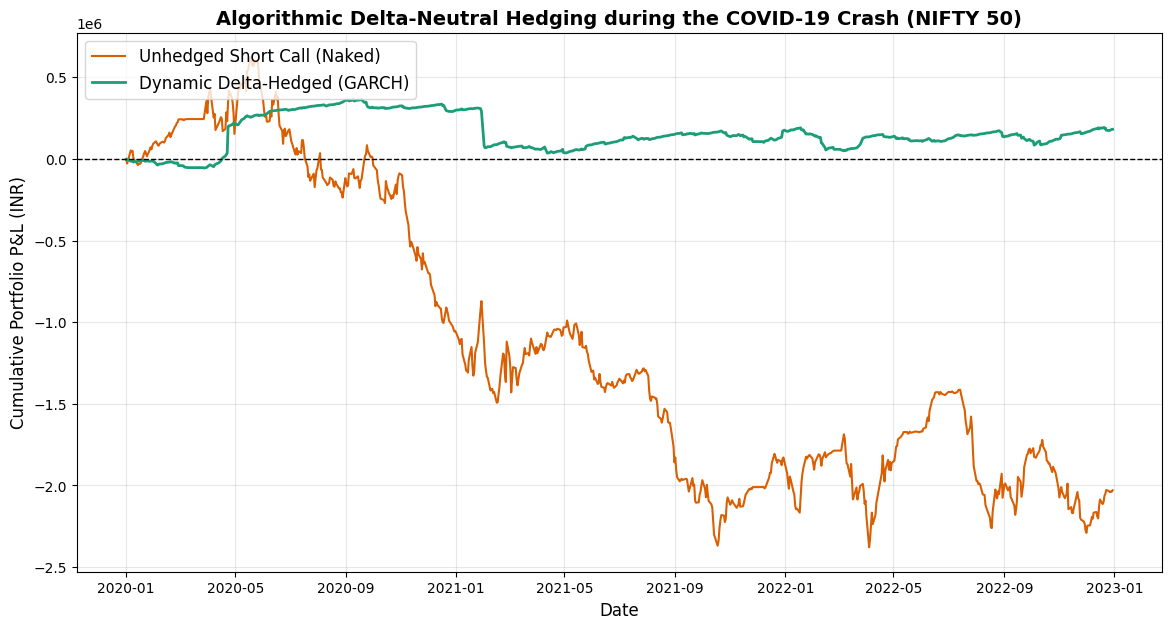

In [ ]:
import matplotlib.pyplot as plt

# Set up the plot size and style
plt.figure(figsize=(14, 7))

# Plot the Naked Short Call
plt.plot(sim_df.index, sim_df['Unhedged_MTM'], 
         color='#d95f02', linewidth=1.5, label='Unhedged Short Call (Naked)')

# Plot the Delta-Hedged Portfolio
plt.plot(sim_df.index, sim_df['Hedged_MTM'], 
         color='#1b9e77', linewidth=2, label='Dynamic Delta-Hedged (GARCH)')

# Formatting
plt.title('Algorithmic Delta-Neutral Hedging during the COVID-19 Crash (NIFTY 50)', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Portfolio P&L (INR)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--') # Break-even line
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)

#Display chart
plt.show()

In [ ]:
import numpy as np

# Starting with nominal starting capital (10 Lakh INR) to calculate standard percentages
starting_capital = 1000000 
rf_rate = 0.05

print("Quantitative Performance Metrics (2020-2022)\n" + "-"*45)

for col in ['Unhedged_MTM', 'Hedged_MTM']:
    # Create a daily portfolio value series
    port_value = starting_capital + sim_df[col]
    daily_returns = port_value.pct_change().dropna()
    
    # 1. Total Return
    total_return = (port_value.iloc[-1] / starting_capital) - 1
    
    # 2. Sharpe Ratio
    excess_returns = daily_returns - (rf_rate / 252)
    sharpe_ratio = np.sqrt(252) * (excess_returns.mean() / excess_returns.std())
    
    # 3. Maximum Drawdown
    rolling_max = port_value.cummax()
    drawdown = (port_value - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # Output formatting
    strategy = "Naked Short Call" if col == 'Unhedged_MTM' else "Dynamic Delta-Hedged"
    print(f"Strategy: {strategy}")
    print(f"  Total Return: {total_return * 100:.2f}%")
    print(f"  Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"  Max Drawdown: {max_drawdown * 100:.2f}%\n")

Quantitative Performance Metrics (2020-2022)
---------------------------------------------
Strategy: Naked Short Call
  Total Return: -202.93%
  Sharpe Ratio: -0.21
  Max Drawdown: -184.92%

Strategy: Dynamic Delta-Hedged
  Total Return: 18.14%
  Sharpe Ratio: 0.13
  Max Drawdown: -24.04%

